# Week 2: Deep Exploratory Analysis & Feature Engineering

## 1. Data Acquisition & Inspection
Loading the Steel Industry Energy Consumption dataset from the local repository structure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

DATA_PATH = os.path.join("data", "Steel_industry_data.csv")

df = pd.read_csv(DATA_PATH)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

## 2. Feature Engineering
Transforming temporal strings into datetime objects to extract actionable cyclical features. Calculating the `Power_Factor_Ratio` and establishing a binary `High_Load` classification threshold at the 75th percentile of total usage.

In [2]:
df.columns = df.columns.str.strip()
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')

df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = np.where(df['day_of_week'] >= 5, 1, 0)

epsilon = 1e-9
df['Power_Factor_Ratio'] = df['Leading_Current_Power_Factor'] / (df['Lagging_Current_Power_Factor'] + epsilon)

threshold_75 = df['Usage_kWh'].quantile(0.75)
df['High_Load'] = np.where(df['Usage_kWh'] > threshold_75, 1, 0)

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,day_of_week,month,is_weekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,0,1.545117,0


## 3. Exploratory Data Analysis & Visualization
Isolating extreme usage events via the Interquartile Range (IQR) method, mapping numerical feature correlations, and analyzing consumption patterns across categorical load types and daily operating hours.

Total outliers detected in Usage_kWh: 328


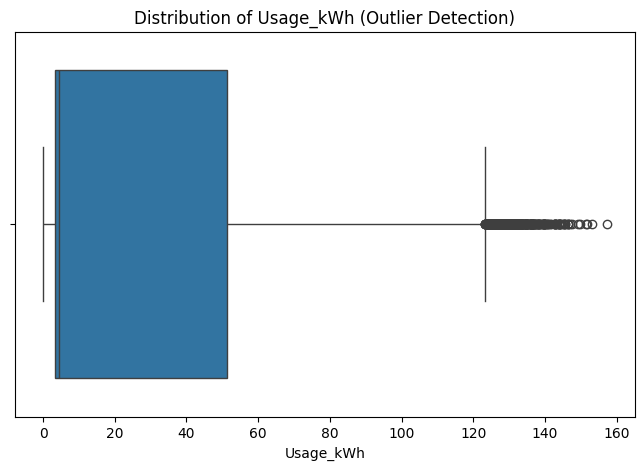

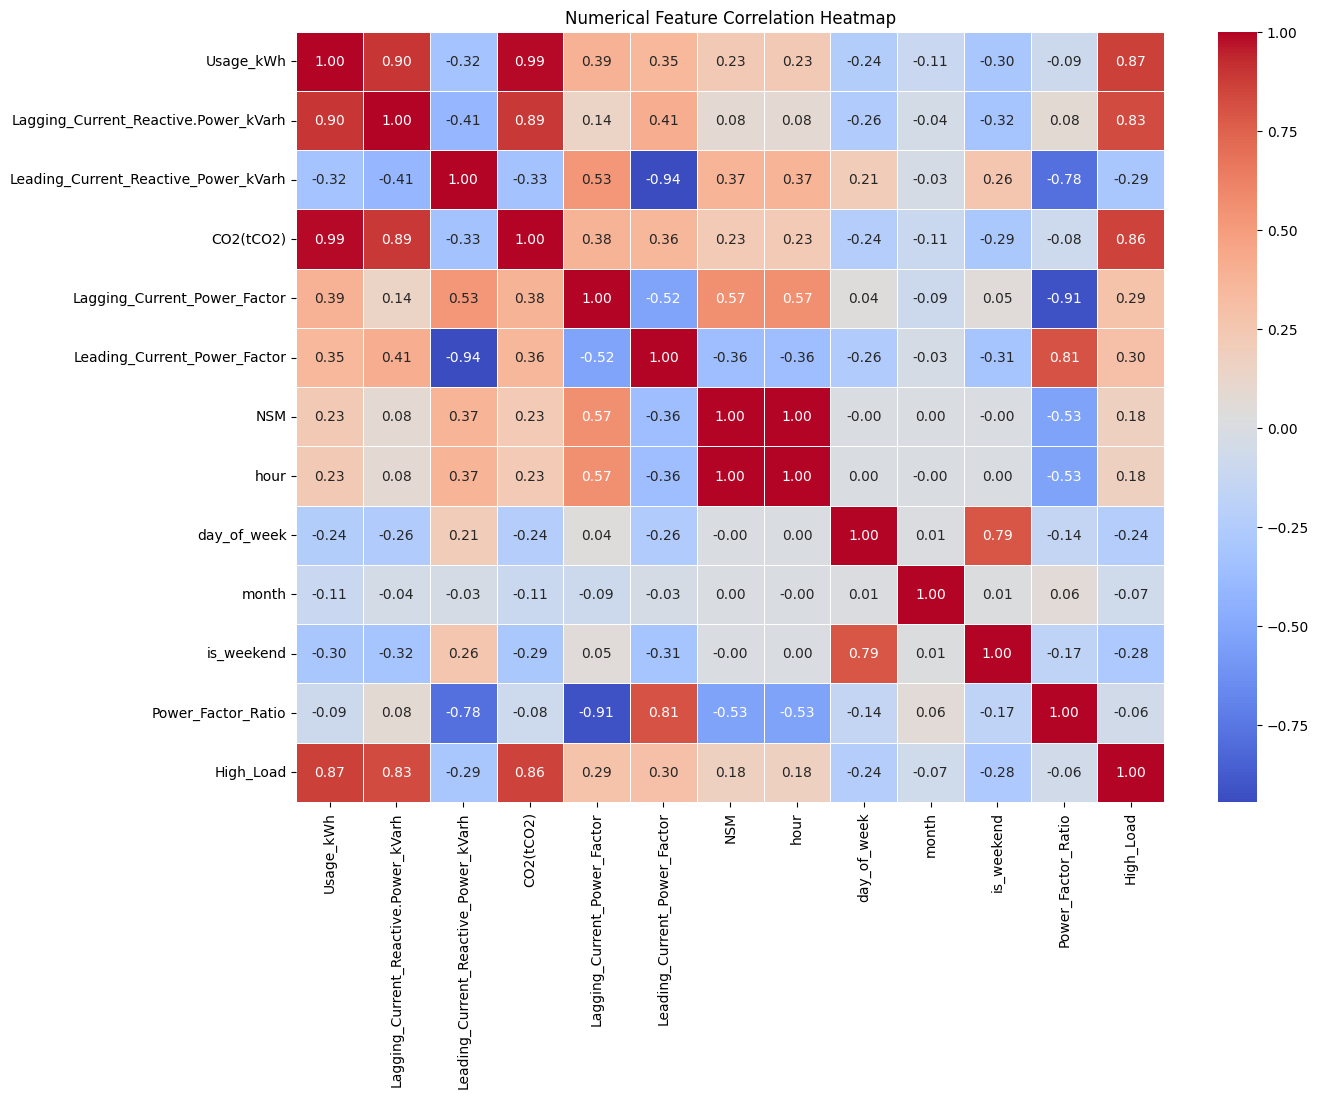

Top 3 correlated features with Usage_kWh:
 ['CO2(tCO2)', 'Lagging_Current_Reactive.Power_kVarh', 'High_Load']


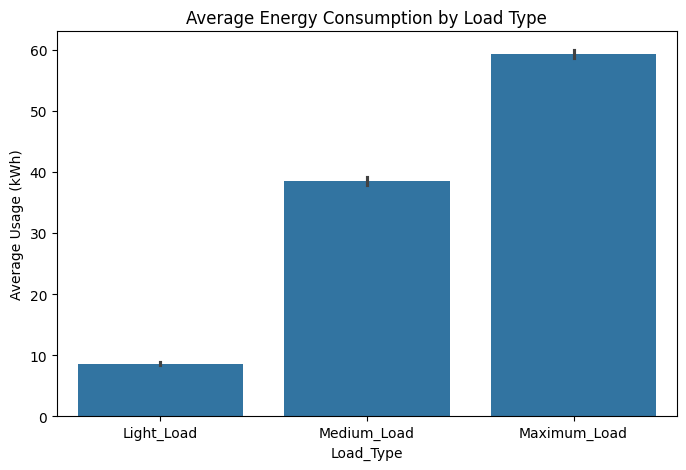

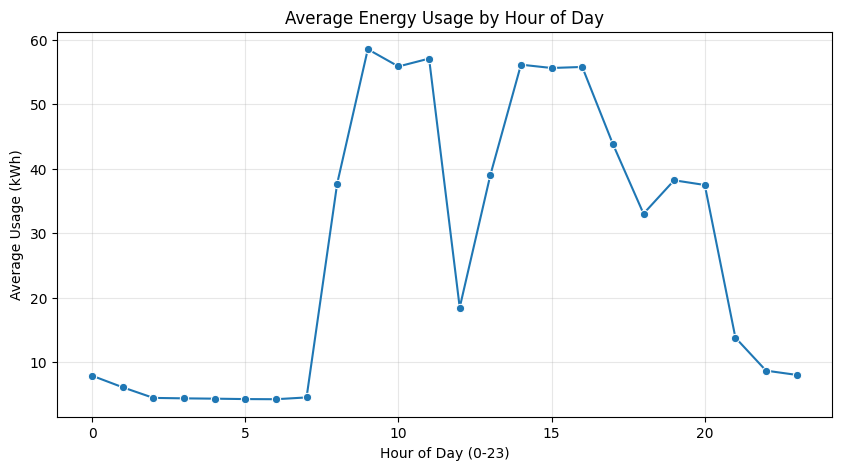

In [3]:

# Outlier Detection (IQR Method)
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]
print(f"Total outliers detected in Usage_kWh: {len(outliers)}")

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Usage_kWh'])
plt.title('Distribution of Usage_kWh (Outlier Detection)')
plt.show()

# Correlation Analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

target_corr = corr_matrix['Usage_kWh'].abs().sort_values(ascending=False)
print("Top 3 correlated features with Usage_kWh:\n", target_corr.index[1:4].tolist())

# Categorical Load Analysis
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Load_Type', y='Usage_kWh', estimator=np.mean)
plt.title('Average Energy Consumption by Load Type')
plt.ylabel('Average Usage (kWh)')
plt.show()

# Temporal Usage Analysis
plt.figure(figsize=(10, 5))
hourly_usage = df.groupby('hour')['Usage_kWh'].mean().reset_index()
sns.lineplot(data=hourly_usage, x='hour', y='Usage_kWh', marker='o')
plt.title('Average Energy Usage by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Usage (kWh)')
plt.grid(True, alpha=0.3)
plt.show()

df.to_csv(os.path.join("data", "Steel_industry_data_engineered.csv"), index=False)

# Part 1

## Exploratory Data Analysis Summary

The initial structural investigation of the Steel Industry Energy Consumption dataset revealed a robust time-series structure requiring targeted feature engineering to extract predictive signals. During the data quality assessment, the IQR method identified **328** outliers within the primary target variable, **Usage_kWh**. These outliers heavily skew toward the upper bound, indicating intermittent, extreme spikes in power draw rather than erroneous sensor readings, which is characteristic of heavy industrial machinery operations.

Correlation analysis across the engineered dataset highlighted the primary drivers of energy consumption. The top three features most strongly correlated with **Usage_kWh** are **CO2(tCO2)**, **Lagging_Current_Reactive.Power_kVarh**, and **High_Load**. The strong relationship with reactive power metrics suggests that the efficiency of the power grid within the plant is closely tied to overall volume consumption.

The most prominent operational pattern discovered is the strict temporal dependency of energy usage. The line chart mapping average consumption by hour demonstrates a distinct cyclical trough during the early morning hours, followed by sustained, elevated consumption throughout standard operational shifts. Furthermore, the grouped bar chart confirms that categorical **"Maximum Load"** designations perfectly align with peak empirical usage.

Based on these distributions, the primary hypothesis is that energy spikes are systematically driven by production scheduling rather than external environmental factors. The sharp transitions between load types and hourly usage suggest that the activation of specific heavy-duty smelting or rolling equipment during designated shifts is the root cause of the isolated high-load outliers observed in the dataset.